**Customer Data Analytics Project**
## Customer Behavioral Insights in Banking Data
**Team:** Julian Purtschert, Samuel Amuzu, Elizaveta Kryukova, Aurora Rigo, Nick Schaufelberger
**Course:** W.MSCIDS_DE_CRA01.H2501 Customer Data Analytics
**Date:** SEP/OCT 2025

---

# Introduction
This document serves as a comprehensive record of our group's work throughout this Customer Data Analytics project. It includes all steps, experiments and code implementations, that show our full analytical thinking process, as well as our technical approach.

It shows our steps taken, trials and challenges we faced along our way. By showing these information, we want to showcase how our project, structure and personal skills evolved over time.

## Research Questions:
Our pre-defined research questions, which guided us through our process.

> *“How do heavy users (in terms of frequency) differ in their daily, weekly, and seasonal spending patterns compared to not heavy users?”*

> *“How can Yapeal use these differences to create timely offers and grow customer loyalty and share of wallet?”*

---

In [106]:
%matplotlib inline

In [107]:
#Load Libraries
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt
#from llvmlite.ir import Aggregate
from calendar import month_name
import numpy as np
import seaborn as sns
from requests.utils import default_user_agent
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Read Transactional Data from 2021, 2022 and 2023 (reproducible version).

In [108]:
from pathlib import Path

# Define the path to your data folder inside OneDrive
DATA_DIR = Path("/Users/nickschaufelberger/Library/CloudStorage/OneDrive-HochschuleLuzern(2)/Customer Data Analytics/UploadFolder/data/raw")

# Confirm access to files
print("Looking for data in:", DATA_DIR.resolve())
print("Files found:", list(DATA_DIR.glob("*.csv")))

# Load datasets
df_transaction_2021 = pd.read_csv(DATA_DIR / "card_transactions_2021.csv")
df_transaction_2022 = pd.read_csv(DATA_DIR / "card_transactions_2022.csv")
df_transaction_2023 = pd.read_csv(DATA_DIR / "card_transactions_2023.csv")

# Combine into one unified DataFrame
df_transaction = pd.concat(
    [df_transaction_2021, df_transaction_2022, df_transaction_2023],
    ignore_index=True
)

print("Combined dataset shape:", df_transaction.shape)
df_transaction.head()

Looking for data in: /Users/nickschaufelberger/Library/CloudStorage/OneDrive-HochschuleLuzern(2)/Customer Data Analytics/UploadFolder/data/raw
Files found: [PosixPath('/Users/nickschaufelberger/Library/CloudStorage/OneDrive-HochschuleLuzern(2)/Customer Data Analytics/UploadFolder/data/raw/card_transactions_2022.csv'), PosixPath('/Users/nickschaufelberger/Library/CloudStorage/OneDrive-HochschuleLuzern(2)/Customer Data Analytics/UploadFolder/data/raw/card_transactions_2023.csv'), PosixPath('/Users/nickschaufelberger/Library/CloudStorage/OneDrive-HochschuleLuzern(2)/Customer Data Analytics/UploadFolder/data/raw/card_transactions_2021.csv')]
Combined dataset shape: (1508900, 9)


,customer_id,country,type,trx_date,amount_chf,orig_currency,category,mcc,counterpart
0,d4c13def-7173-4d71-a2a7-11a8b3e4db5f,ie,ecom,2021-01-01T00:06:27Z,25.5,chf,communication,5818.0,Apple
1,e6315ccb-076d-40dd-9821-d57ad47d07fd,ch,ecom,2021-01-01T00:20:09Z,19.9,chf,communication,4899.0,Sky
2,b6609a82-4d46-49ae-a273-588475160457,ch,ecom,2021-01-01T00:21:37Z,100.0,chf,communication,5734.0,COMMUNITYRACK.ORG
3,6e341a58-147c-4716-a6f0-220970ffb069,ch,ecom,2021-01-01T00:23:46Z,23.9,chf,general,8999.0,PAYPAL
4,6e341a58-147c-4716-a6f0-220970ffb069,ch,ecom,2021-01-01T00:27:29Z,12.4,chf,general,8999.0,PAYPAL


Structure of 2021, 2022 and 2023 data

In [109]:
# Print the head of the data
print(df_transaction_2021.head())

# Print the dimensions of the data
print(df_transaction_2021.shape)

# Print the row index
print(df_transaction_2021.index)

# Check whether columns are in the correct data type
print(df_transaction_2021.info())

                            customer_id country  type              trx_date  \
0  d4c13def-7173-4d71-a2a7-11a8b3e4db5f      ie  ecom  2021-01-01T00:06:27Z   
1  e6315ccb-076d-40dd-9821-d57ad47d07fd      ch  ecom  2021-01-01T00:20:09Z   
2  b6609a82-4d46-49ae-a273-588475160457      ch  ecom  2021-01-01T00:21:37Z   
3  6e341a58-147c-4716-a6f0-220970ffb069      ch  ecom  2021-01-01T00:23:46Z   
4  6e341a58-147c-4716-a6f0-220970ffb069      ch  ecom  2021-01-01T00:27:29Z   

   amount_chf orig_currency       category   mcc        counterpart  
0        25.5           chf  communication  5818              Apple  
1        19.9           chf  communication  4899                Sky  
2       100.0           chf  communication  5734  COMMUNITYRACK.ORG  
3        23.9           chf        general  8999            PAYPAL   
4        12.4           chf        general  8999            PAYPAL   
(343601, 9)
RangeIndex(start=0, stop=343601, step=1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34

In [110]:
# Print the head of the data
print(df_transaction_2022.head())

# Print the dimensions of the data
print(df_transaction_2022.shape)

# Print the row index
print(df_transaction_2022.index)

# Check whether columns are in the correct data type
print(df_transaction_2022.info())

                            customer_id country  type              trx_date  \
0  d4c13def-7173-4d71-a2a7-11a8b3e4db5f      ie  ecom  2022-01-01T00:01:36Z   
1  2db75b51-0c5d-48a0-b35c-f947d98ed764      fr  ecom  2022-01-01T00:03:12Z   
2  95ed4f2d-5f34-48eb-92d7-e2a30a6d1168      ch  ecom  2022-01-01T00:03:47Z   
3  8483a78d-5180-430d-8060-6ef0d31fb295      ch   pos  2022-01-01T00:05:34Z   
4  911d1470-1119-45df-ad58-bc77c2698ca8      ch   pos  2022-01-01T00:17:34Z   

   amount_chf orig_currency       category     mcc        counterpart  
0       25.50           chf  communication  5735.0              Apple  
1       15.56           eur  entertainment  7993.0            UBISOFT  
2        8.40           chf      transport  4789.0  SBB Mobile Ticket  
3       12.00           chf    restaurants  5812.0    Lady Hamilton's  
4       70.00           chf    restaurants  5813.0            Zukunft  
(536181, 9)
RangeIndex(start=0, stop=536181, step=1)
<class 'pandas.core.frame.DataFrame'>
Ra

In [111]:
# Print the head of the data
print(df_transaction_2023.head())

# Print the dimensions of the data
print(df_transaction_2023.shape)

# Print the row index
print(df_transaction_2023.index)

# Check whether columns are in the correct data type
print(df_transaction_2023.info())

                            customer_id country  type              trx_date  \
0  88a27d10-ea7e-4989-af14-df1f9f1d9db4      ch   pos  2022-12-31T23:59:58Z   
1  699e0b57-06b4-4f22-a571-7209327d7d20      us   pos  2023-01-01T00:00:44Z   
2  02928ca6-342d-4de9-aa6e-3a6afe40aacf      us   pos  2023-01-01T00:01:00Z   
3  6723e6c2-372c-48e3-87e3-21839baa95f3      ch   pos  2023-01-01T00:02:26Z   
4  08112684-e51b-4b14-9853-f05b4ddb4520      fr  ecom  2023-01-01T00:03:22Z   

   amount_chf orig_currency     category     mcc               counterpart  
0       15.00           chf  restaurants  5813.0                   SumUp    
1      342.74           usd     shopping  5999.0          MR FIREWORKS 508  
2       19.31           usd     shopping  5310.0             TARGET T-0201  
3        4.80           chf  restaurants  5813.0  WEISSE ARENA HOSPITALITY  
4        5.89           eur    transport  4789.0                       LIM  
(629118, 9)
RangeIndex(start=0, stop=629118, step=1)
<class 'pa

We combined all yearly transaction datasets (2021-2023) into a single DataFrame to create one unified table for further analysis and visualization.

In [112]:
# Concatenate all transactional data into one data frame
df_transaction = pd.concat([df_transaction_2021, df_transaction_2022, df_transaction_2023], ignore_index = True)

# Explore concatenated data
print(df_transaction.head())

# Explore data types
print(df_transaction.info())

                            customer_id country  type              trx_date  \
0  d4c13def-7173-4d71-a2a7-11a8b3e4db5f      ie  ecom  2021-01-01T00:06:27Z   
1  e6315ccb-076d-40dd-9821-d57ad47d07fd      ch  ecom  2021-01-01T00:20:09Z   
2  b6609a82-4d46-49ae-a273-588475160457      ch  ecom  2021-01-01T00:21:37Z   
3  6e341a58-147c-4716-a6f0-220970ffb069      ch  ecom  2021-01-01T00:23:46Z   
4  6e341a58-147c-4716-a6f0-220970ffb069      ch  ecom  2021-01-01T00:27:29Z   

   amount_chf orig_currency       category     mcc        counterpart  
0        25.5           chf  communication  5818.0              Apple  
1        19.9           chf  communication  4899.0                Sky  
2       100.0           chf  communication  5734.0  COMMUNITYRACK.ORG  
3        23.9           chf        general  8999.0            PAYPAL   
4        12.4           chf        general  8999.0            PAYPAL   
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1508900 entries, 0 to 1508899
Data columns 

We explored all transaction categories in the dataset to identify the most frequent spending areas. This allowed us to focus on the top four segments: Transport, Shopping, Groceries, and Restaurants, as the key categories for analyzing customer behavior and developing persona-based insights.

In [113]:
# Identifying the categories
df_transaction["category"].unique()
df_transaction["category"].value_counts()

category
groceries              489725
restaurants            286863
transport              223419
shopping               170525
communication          102011
entertainment           80499
holidays                43907
cash                    36340
health                  32269
general                 19975
tax                      8064
living                   7756
savings                  6564
wellness                  562
education                 146
Restaurant                118
salary                     58
Groceries                  34
Shopping                   17
GVS Markt                  16
Health                     14
Holidays                    7
Fitness                     5
Hotel                       3
Lebensmittel                2
 Ristorante Mercato         1
Name: count, dtype: int64

We grouped all transactions by category and summed their total spending amounts to visualize how customers distribute their spending. The top seven categories were highlighted, while smaller ones were combined into an “Other” group, resulting in a pie chart overview of overall spending patterns.

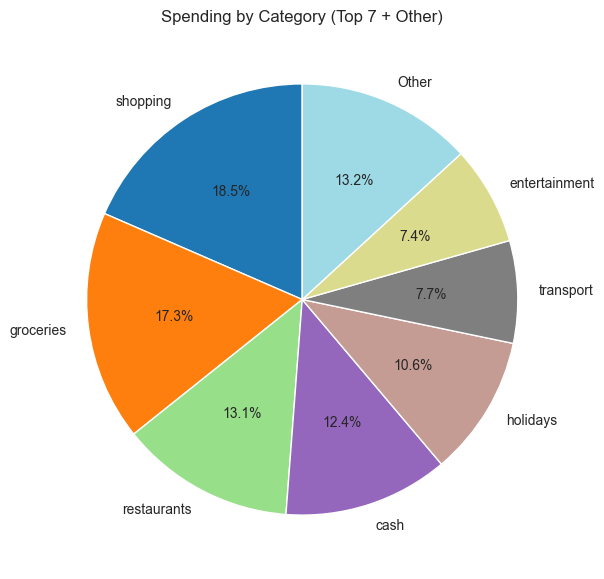

In [114]:
# Group by category and sum
df_category = df_transaction.groupby("category")["amount_chf"].sum()

# Sort and group small ones into Other
df_category_sorted = df_category.sort_values(ascending=False)
top = df_category_sorted.head(7)
other = pd.Series(df_category_sorted.iloc[7:].sum(), index=["Other"])

# Combine top categories with Other
df_category_clean = pd.concat([top, other])

# Plot Pie Chart
df_category_clean.plot.pie(
    autopct='%1.1f%%',
    figsize=(7,7),
    startangle=90,
    ylabel="",
    colormap="tab20"
)

plt.title("Spending by Category (Top 7 + Other)")
plt.show()

We identified the four categories with the highest total spending and filtered the dataset to include only those. This reduced the data to the most relevant segments for deeper analysis of customer behavior and spending patterns.

In [115]:
# Identifying top 4 categories by total spend
top4_categories = (
    df_transaction.groupby("category")["amount_chf"]
    .sum()
    .nlargest(4)        # get top 4
    .index              # extract category names
)

# Filtering df_transaction to keep only those top 4 categories
df_top4 = df_transaction[df_transaction["category"].isin(top4_categories)].copy()

# Exploring new data frame
df_top4.head()
df_top4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 983453 entries, 5 to 1508899
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   customer_id    983453 non-null  object 
 1   country        983453 non-null  object 
 2   type           983453 non-null  object 
 3   trx_date       983453 non-null  object 
 4   amount_chf     983453 non-null  float64
 5   orig_currency  983453 non-null  object 
 6   category       983453 non-null  object 
 7   mcc            983453 non-null  float64
 8   counterpart    983348 non-null  object 
dtypes: float64(2), object(7)
memory usage: 75.0+ MB


In [116]:
# To view the date column
df_top4["trx_date"]

# To confirm the structure of the date
max(df_top4["trx_date"])

'2023-12-31T23:57:58Z'

Converting object date type to an actual date type.

In [117]:
# Converting the trx_date from an object to a date
df_top4["trx_date"] = pd.to_datetime(df_top4["trx_date"], errors="coerce")


# Confirming changes
df_top4["trx_date"]
print(df_top4.dtypes)

customer_id                   object
country                       object
type                          object
trx_date         datetime64[ns, UTC]
amount_chf                   float64
orig_currency                 object
category                      object
mcc                          float64
counterpart                   object
dtype: object


We visualized the total spending over time to get an overall view of transaction trends across the years, helping us spot seasonal patterns, spending peaks, or changes in customer activity.

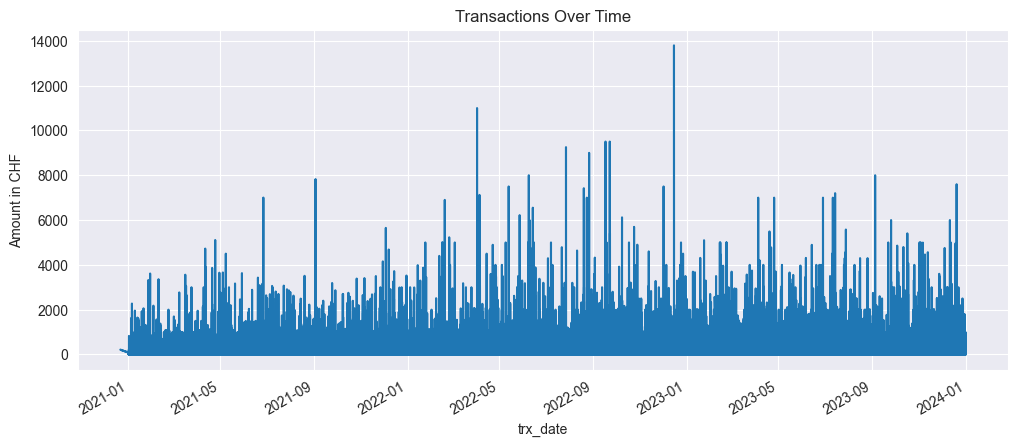

In [118]:
# Visualising amounts spent across the years
df_time_series = df_top4.set_index("trx_date")
df_time_series["amount_chf"].plot(figsize=(12,5),
                                  title="Transactions Over Time")
plt.ylabel("Amount in CHF")
plt.show()

We analyzed total spending per category on a yearly level to understand how customer preferences and spending behavior evolved over time across the main segments.

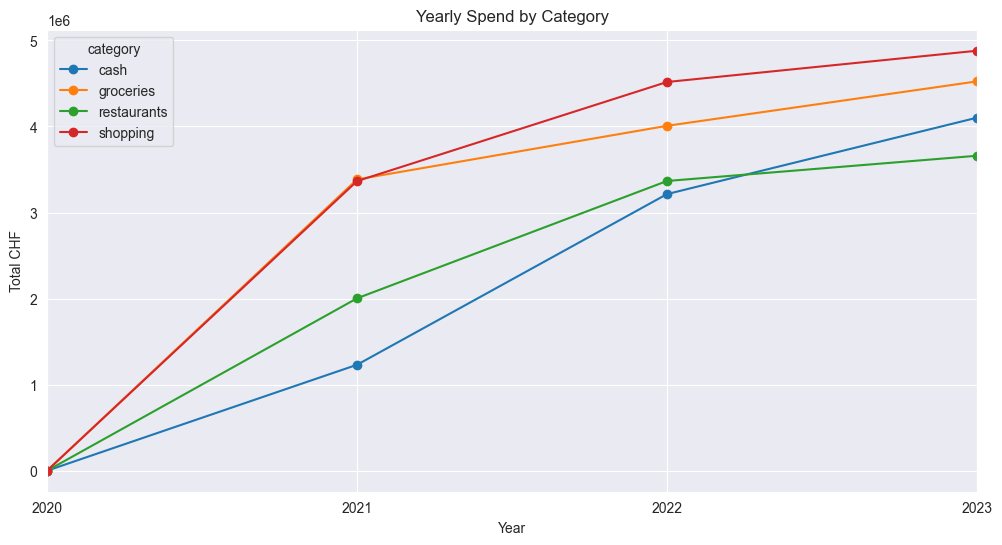

In [119]:
# Setting the trx_date as the index
df_ts = df_top4.set_index("trx_date").sort_index()

# Visualisation for Yearly totals by Category
df_yearly = (
    df_ts.groupby("category")["amount_chf"]
    .resample("YE")
    .sum()
    .unstack("category", fill_value=0)
)

df_yearly.plot(marker="o", figsize=(12, 6), title="Yearly Spend by Category")
plt.ylabel("Total CHF")
plt.xlabel("Year")
plt.show()

We aggregated transaction data by month and category to analyze spending trends at a finer time resolution. This monthly time series visualization reveals recurring patterns and seasonal fluctuations in customer spending behavior across categories.

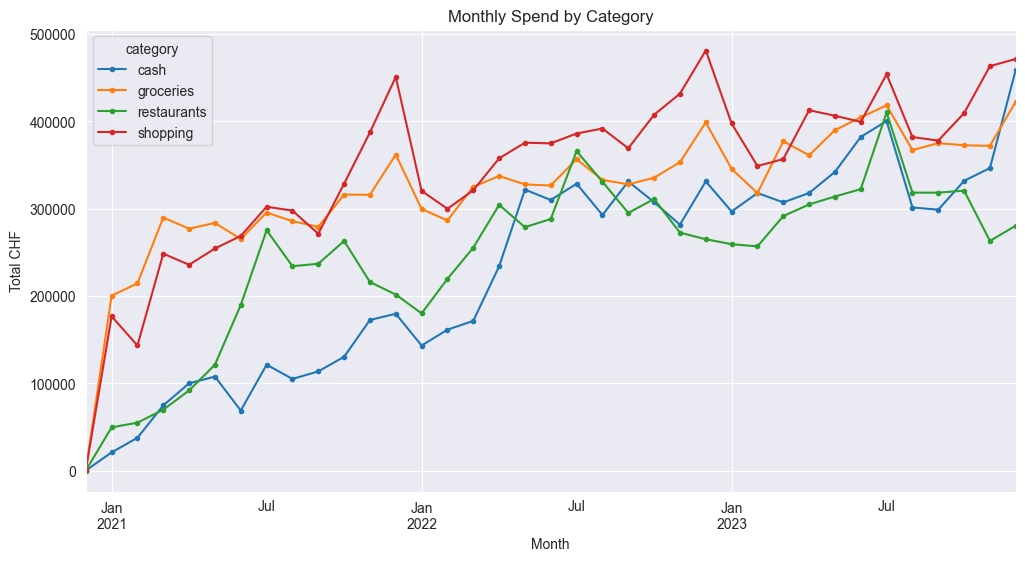

In [120]:
# Preparing data for Monthly time series analysis
df_monthly = (
    df_ts.groupby("category")["amount_chf"]
         .resample("ME")
         .sum()
         .unstack("category", fill_value=0)
)

# Plot
df_monthly.plot(marker=".", figsize=(12,6), title="Monthly Spend by Category")
plt.ylabel("Total CHF")
plt.xlabel("Month")
plt.show()

We calculated the average monthly spending for each category across all years to highlight seasonal spending trends. This visualization helps identify which months see higher or lower spending activity in each category, revealing potential periods for targeted marketing or promotions.

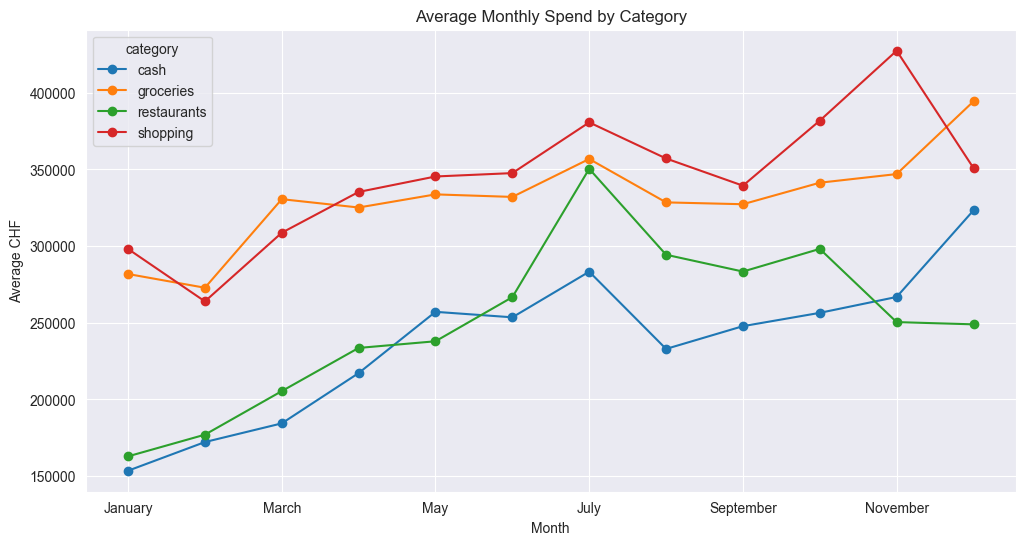

In [121]:
# Preparing data for time series analysis
df_month_names = (
    df_top4
      .set_index("trx_date")
      .groupby("category")["amount_chf"]
      .resample("ME").sum()
      .reset_index()
)

df_month_names["Month"] = df_month_names["trx_date"].dt.month_name()

# Average spend by month across all years
monthly_avg = df_month_names.groupby(["Month","category"])["amount_chf"].mean().unstack("category")

# Reorder months in order
from calendar import month_name
monthly_avg = monthly_avg.reindex(list(month_name[1:]))

# Plot
monthly_avg.plot(marker="o", figsize=(12,6), title="Average Monthly Spend by Category")
plt.ylabel("Average CHF")
plt.xlabel("Month")
plt.show()

We analyzed total spending by day of the week to uncover when customers are most active in each category. This allows us to detect weekly spending patterns, such as higher restaurant or shopping activity on weekends compared to weekdays.

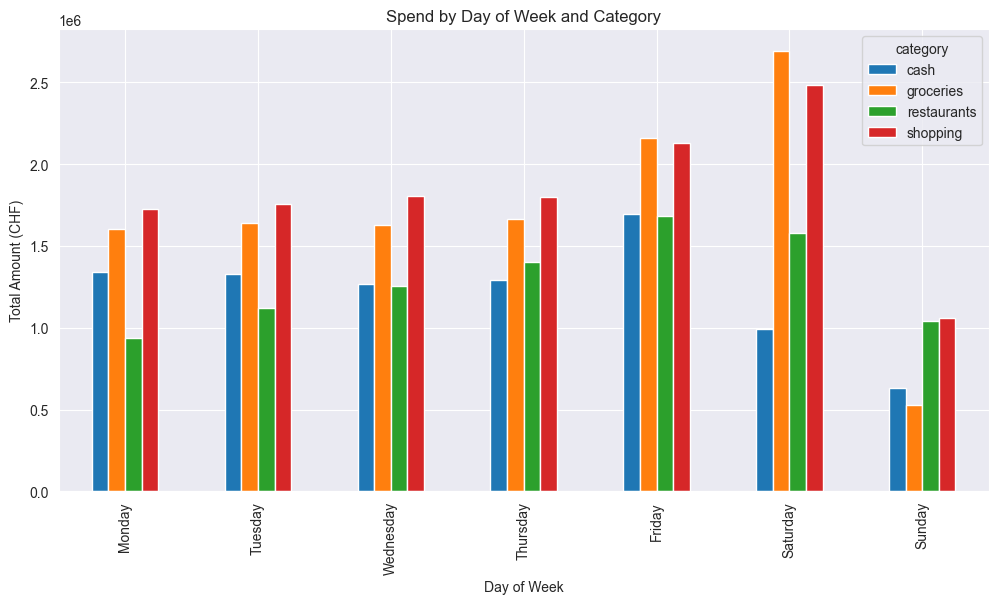

In [122]:
# Adding a weekday column
df_top4["weekday"] = df_top4["trx_date"].dt.day_name()

# Grouping by weekday and category
df_weekday = (
    df_top4.groupby(["weekday", "category"])["amount_chf"]
           .sum()
           .unstack("category", fill_value=0)
)

# Reordering weekdays in a specific order of the weekly days
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df_weekday = df_weekday.reindex(weekday_order)

# Plot
df_weekday.plot(kind="bar", figsize=(12,6))
plt.title("Spend by Day of Week and Category")
plt.ylabel("Total Amount (CHF)")
plt.xlabel("Day of Week")
plt.show()

We examined transaction patterns across different time dimensions, by year, by month within each year, and by individual days, to gain deeper insights into how customer activity fluctuates over time and to identify consistent seasonal or temporal spending trends.

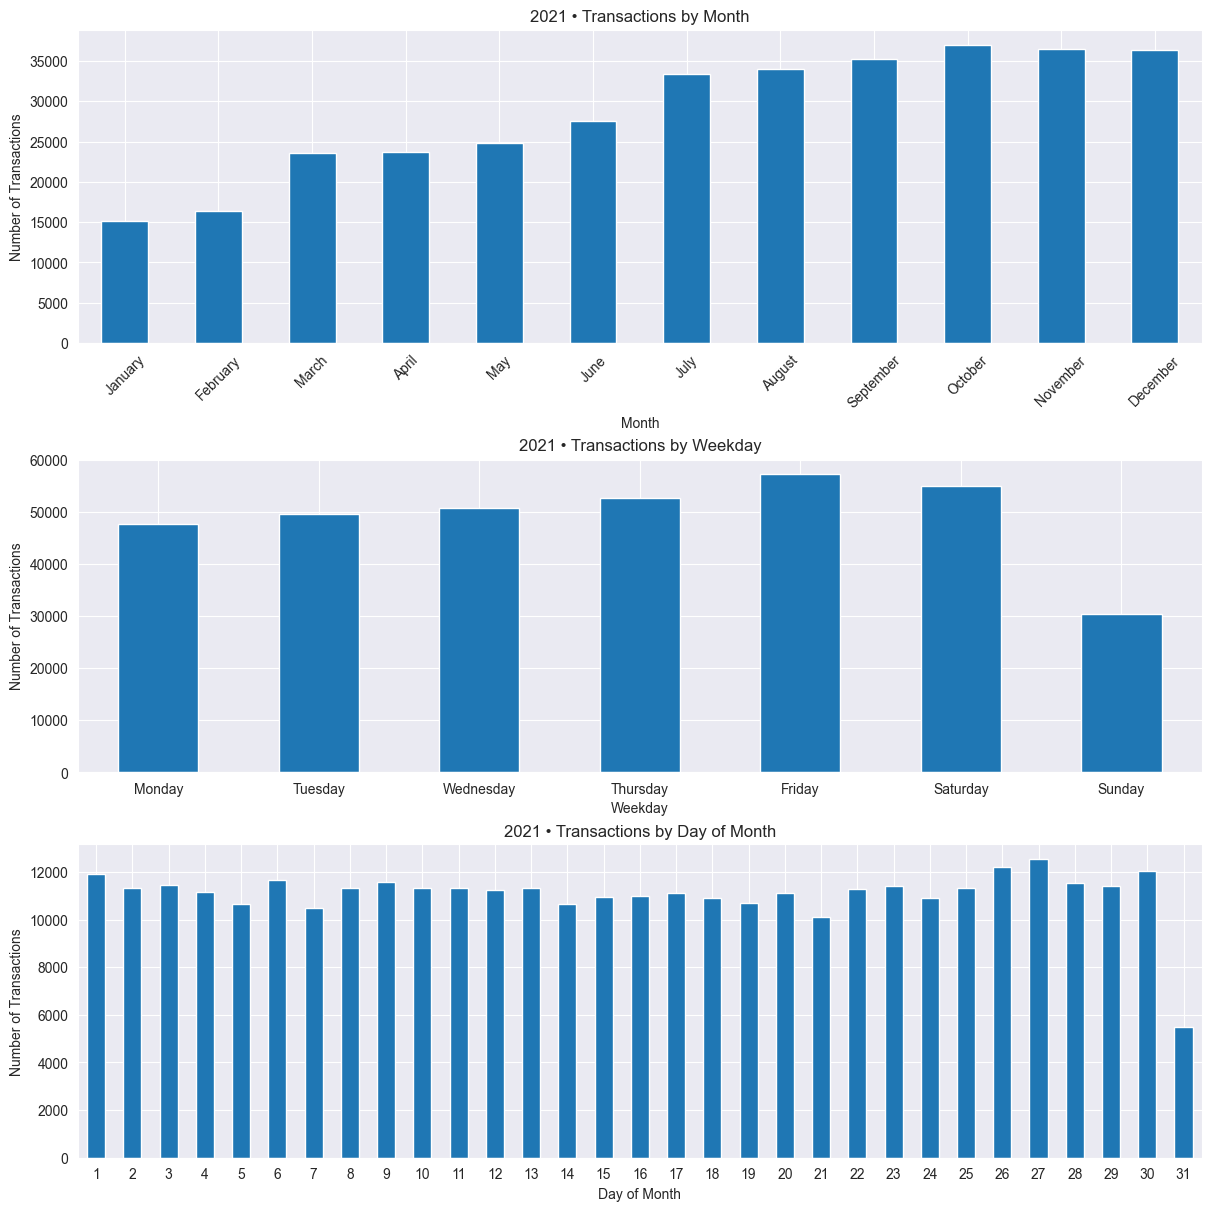

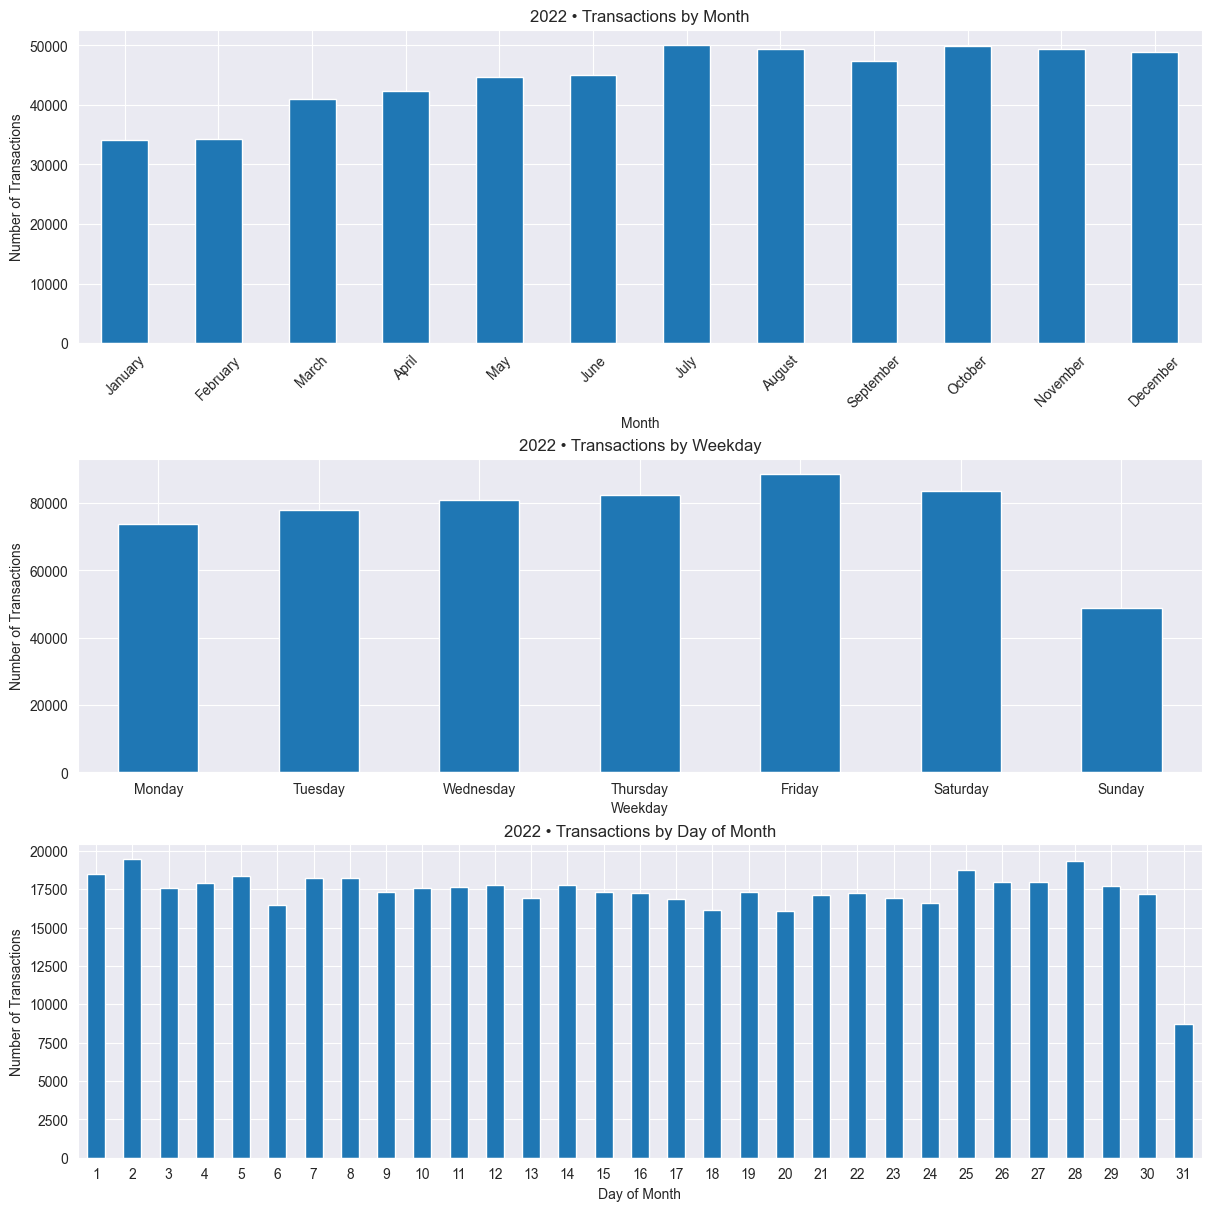

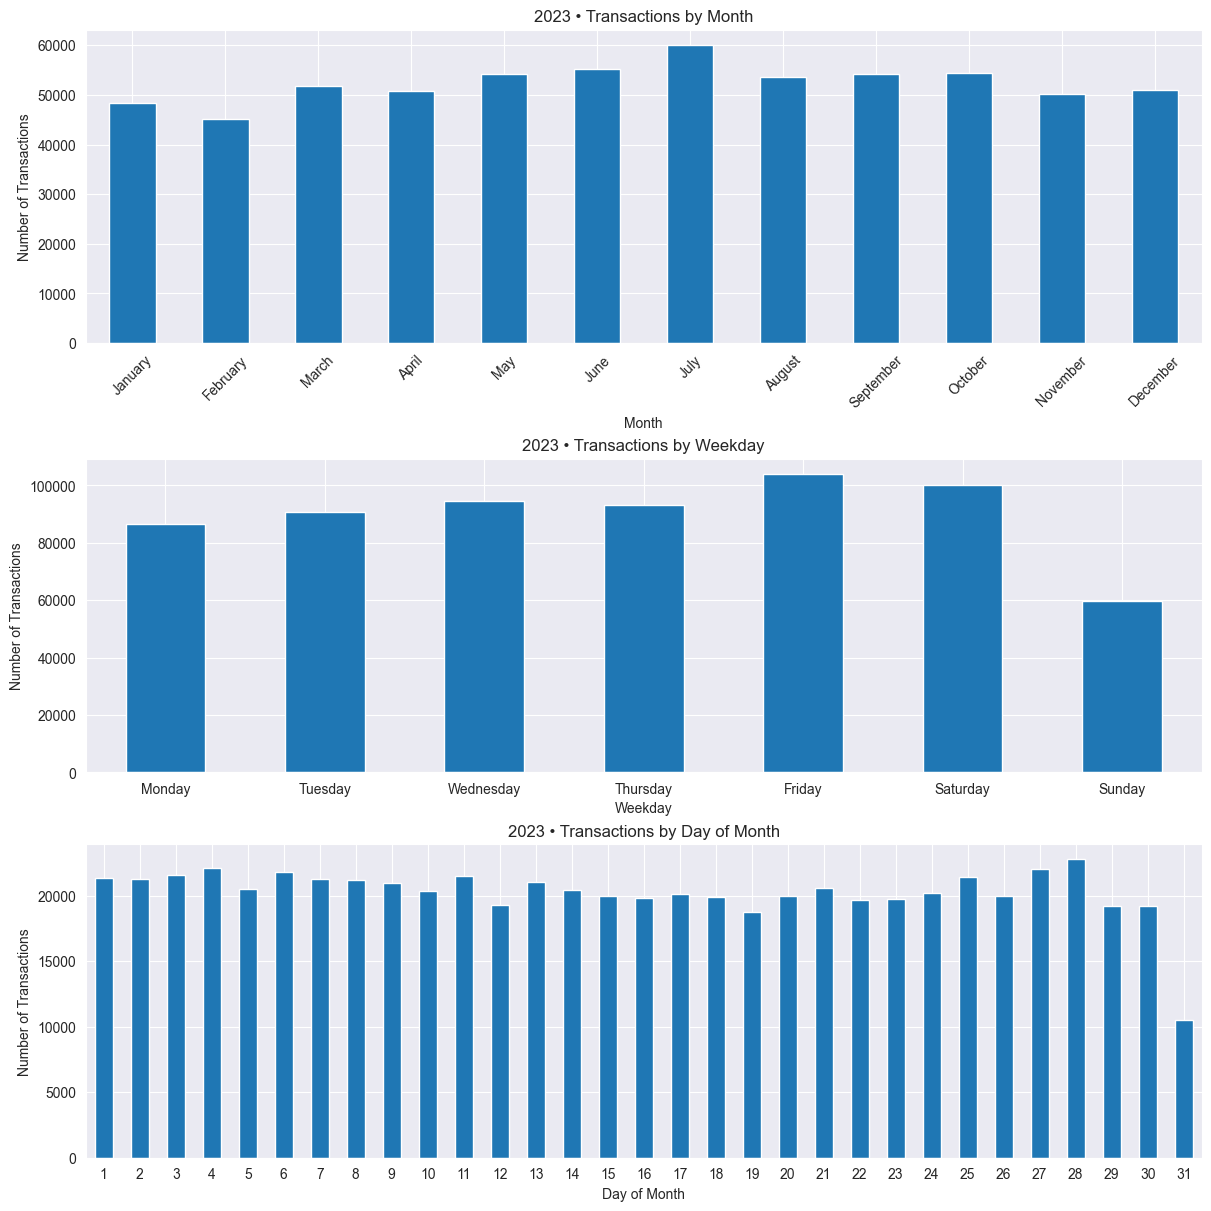

In [123]:
# Data Preparation
df = df_transaction.copy()
df["trx_date"] = pd.to_datetime(df["trx_date"], errors="coerce")
df = df.dropna(subset=["trx_date"])

# List to Order axis
MONTHS = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]
WEEKDAYS = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

def plot_year_counts(df, year):
    d = df[df["trx_date"].dt.year == year].copy()
    if d.empty:
        print(f"No data for {year}")
        return

    # Month, weekday, day-of-month columns (ordered)
    d["month_name"] = pd.Categorical(d["trx_date"].dt.month_name(),
                                     categories=MONTHS, ordered=True)
    d["weekday"]    = pd.Categorical(d["trx_date"].dt.day_name(),
                                     categories=WEEKDAYS, ordered=True)
    d["day_of_month"] = d["trx_date"].dt.day

    # Monthly counts from January to December for each year
    monthly = (
        d.groupby("month_name", observed = True).size().astype("int64").reindex(MONTHS)
    )

    # Weekday counts from Monday to Sunday for each year
    wday = (
        d.groupby("weekday", observed = True).size().astype("int64").reindex(WEEKDAYS)
    )

    # Day of month counts from 1st to 31st
    dom = (
        d.groupby("day_of_month").size().astype("int64")
        .reindex(range(1,32), fill_value=0)
    )

    # Plotting 3 separate panels for each year
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)

    monthly.plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"{year} • Transactions by Month")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Number of Transactions")
    axes[0].tick_params(axis='x', rotation=45)

    wday.plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"{year} • Transactions by Weekday")
    axes[1].set_xlabel("Weekday")
    axes[1].set_ylabel("Number of Transactions")
    axes[1].tick_params(axis='x', rotation=0)

    dom.plot(kind="bar", ax=axes[2])
    axes[2].set_title(f"{year} • Transactions by Day of Month")
    axes[2].set_xlabel("Day of Month")
    axes[2].set_ylabel("Number of Transactions")
    axes[2].tick_params(axis='x', labelrotation=0)

    plt.show()

# Calling year for each year with the data frame
for yr in (2021, 2022, 2023):
    plot_year_counts(df, yr)

We prepared the dataset for clustering by ensuring that the transaction date column was correctly formatted as a datetime object. This step is essential for accurate time-based grouping and further preprocessing before applying K-Means clustering to segment customers.

In [124]:
# Converting trx_date into date data type
df_transaction["trx_date"] = pd.to_datetime(df_transaction["trx_date"], errors="coerce")
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1508900 entries, 0 to 1508899
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype              
---  ------         --------------    -----              
 0   customer_id    1508900 non-null  object             
 1   country        1508897 non-null  object             
 2   type           1508897 non-null  object             
 3   trx_date       1508899 non-null  datetime64[ns, UTC]
 4   amount_chf     1508900 non-null  float64            
 5   orig_currency  1508897 non-null  object             
 6   category       1508900 non-null  object             
 7   mcc            1508896 non-null  float64            
 8   counterpart    1508782 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(2), object(6)
memory usage: 103.6+ MB


We calculated key customer metrics, Recency, Frequency, and Monetary (RFM), from the full transaction dataset. These KPIs quantify how recently, how often, and how much each customer spends, forming the foundation for clustering them into heavy and normal user segments.

In [125]:
# Creating a reference date
reference_date = df_transaction["trx_date"].max() + pd.Timedelta(days=1)

# Computing features per customer: Recency (the days since the last transaction), frequency (number of transactions) and Monetary (total spending) per customer
# Recency = reference date - last purchase date
# Frequency = counts of transaction per customer
# Monetary = Sum of Amounts spent per customer
df_rfm = (
    df_transaction
    .groupby("customer_id")
    .agg(
        Recency = ("trx_date", lambda x: (reference_date - x.max()).days),
        Frequency = ("trx_date", "count"),
        Monetary = ("amount_chf", "sum")
    )
    .reset_index()
)

In [126]:
# Standardizing the features for comparison on the same scale
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm[["Recency", "Frequency", "Monetary"]])

# Clustering the customers
model = KMeans(n_clusters=2, random_state=42)
model.fit(rfm_scaled)

# Fitting model on data with a new column showing which clusters they belong to
df_rfm["cluster"] = model.fit_predict(rfm_scaled)

# Inspect cluster results
df_rfm.groupby("cluster").mean(numeric_only = True)

# Label heavy vs normal users based on averages
df_rfm["user_type"] = np.where(df_rfm["cluster"] == 0, "heavy", "normal")

Based on the mean RFM values, we interpreted the clusters to identify behavioral segments. Cluster 1 represents heavy users who purchase frequently, spend more, and have recent activity, while Cluster 0 represents normal users with fewer, less recent transactions and lower spending levels.

3D Plot Visualisation

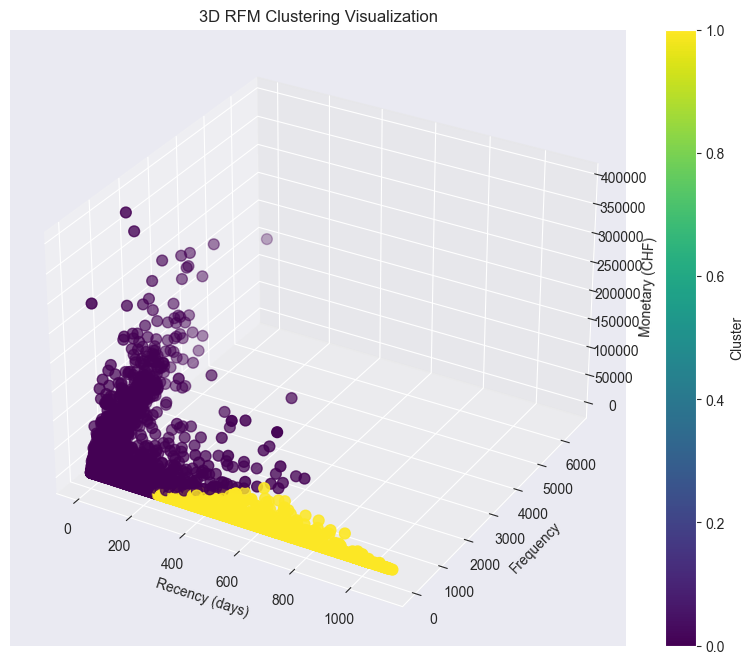

In [127]:
# 3D Plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_rfm["Recency"],
    df_rfm["Frequency"],
    df_rfm["Monetary"],
    c=df_rfm["cluster"],
    cmap="viridis",
    s=60
)

ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary (CHF)")
ax.set_title("3D RFM Clustering Visualization")
plt.colorbar(sc, label="Cluster")
plt.show()

In [128]:
df_rfm.groupby("cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

,Recency,Frequency,Monetary
cluster,,,
0,58.93,394.22,18125.97
1,670.16,33.74,1419.02


In [129]:
# Cluster summary for all customers
cluster_summary = df_rfm[["customer_id", "cluster", "Recency", "Frequency", "Monetary"]]
display(cluster_summary.head(20))

,customer_id,cluster,Recency,Frequency,Monetary
0,00007c83-96c3-4a3c-bbe0-dbca23348700,0,68,27,705.46
1,00070ba2-9737-4159-8ab8-ed089f6b14f3,1,824,5,1436.73
2,0013ca61-beb3-4a9c-b6d5-99aa56da3714,1,579,50,1412.00
3,001c493d-a777-4e94-9888-2feb4d3fadd8,1,488,6,793.57
4,0025c2f7-91b0-44b7-aa17-5a0261b560a1,0,221,147,3969.80
5,0037c3b3-2b49-4880-8098-2596726d0f0c,0,208,2,2.45
6,003e3d5c-0fc3-49db-9a53-027e6009f19d,1,529,101,4672.45
7,007705b7-1e74-457b-b305-c6c80b9bf9be,0,2,1047,90482.55
8,00998a2f-6e97-48df-b0fd-2ee354673701,0,67,1466,108105.91
9,009f0614-0324-4b7d-804b-8d206dc37b5c,0,11,5,261.57


In [130]:
print(df_rfm.head(n=10))

                            customer_id  Recency  Frequency   Monetary  \
0  00007c83-96c3-4a3c-bbe0-dbca23348700       68         27     705.46   
1  00070ba2-9737-4159-8ab8-ed089f6b14f3      824          5    1436.73   
2  0013ca61-beb3-4a9c-b6d5-99aa56da3714      579         50    1412.00   
3  001c493d-a777-4e94-9888-2feb4d3fadd8      488          6     793.57   
4  0025c2f7-91b0-44b7-aa17-5a0261b560a1      221        147    3969.80   
5  0037c3b3-2b49-4880-8098-2596726d0f0c      208          2       2.45   
6  003e3d5c-0fc3-49db-9a53-027e6009f19d      529        101    4672.45   
7  007705b7-1e74-457b-b305-c6c80b9bf9be        2       1047   90482.55   
8  00998a2f-6e97-48df-b0fd-2ee354673701       67       1466  108105.91   
9  009f0614-0324-4b7d-804b-8d206dc37b5c       11          5     261.57   

   cluster user_type  
0        0     heavy  
1        1    normal  
2        1    normal  
3        1    normal  
4        0     heavy  
5        0     heavy  
6        1    normal  
7

We evaluated the K-Means clustering performance using the Elbow Method, which plots the inertia (within-cluster variance) against the number of clusters. This helps identify the optimal number of clusters where adding more clusters no longer significantly reduces inertia, ensuring a balanced and meaningful segmentation.

11889.89788505687


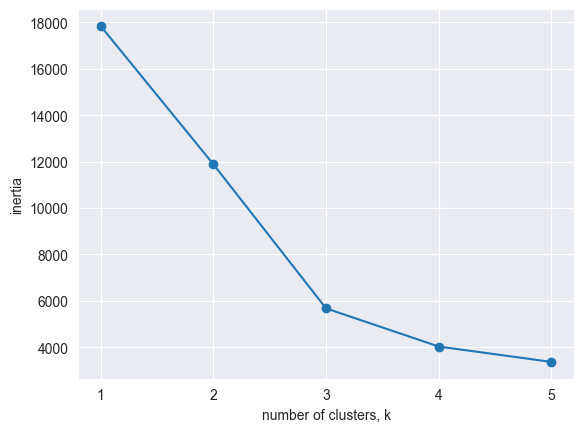

In [131]:
# Evaluating Our model with 2 clusters
print(model.inertia_)

# Producing an Elbow method plot to identify the best number of clusters for our data
ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans model with k clusters
    model = KMeans(n_clusters=k)

    # Fit model to data
    model.fit(rfm_scaled)

    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

We refined our segmentation approach after analyzing the clustering results. Instead of distinguishing only between heavy and normal users, we identified that a three-cluster solution better represents the data, allowing us to classify customers into heavy, normal, and low-activity users based on their spending frequency, recency, and total amount spent.

In [132]:
# Making a copy of our rfm data
rfm_new_df = df_rfm.copy()

#Standardizing the features for comparison on the same scale
scaler = StandardScaler()
rfm_new_scaled = scaler.fit_transform(rfm_new_df[["Recency", "Frequency", "Monetary"]])

In [133]:
# Clustering the customers
model_1 = KMeans(n_clusters=3, random_state=42)
model_1.fit(rfm_new_scaled)

#fitting model on data with a new column showing which clusters they belong to
rfm_new_df["cluster"] = model_1.fit_predict(rfm_new_scaled)

In [134]:
# Inspect cluster results
rfm_new_df.groupby("cluster").mean(numeric_only = True)

,Recency,Frequency,Monetary
cluster,,,
0,31.310573,1577.176211,77478.736696
1,735.258577,35.991295,1522.520845
2,89.905985,204.000565,8730.226911


In [135]:
# Label heavy, normal, and low users based on cluster number after checking averages
conditions = [
    (rfm_new_df["cluster"] == 0),
    (rfm_new_df["cluster"] == 1),
    (rfm_new_df["cluster"] == 2)
]
level = ["heavy", "low", "normal"]

rfm_new_df["user_type"] = np.select(conditions, level, default="unknown")

In [136]:
print(rfm_new_df.head(n=10))

                            customer_id  Recency  Frequency   Monetary  \
0  00007c83-96c3-4a3c-bbe0-dbca23348700       68         27     705.46   
1  00070ba2-9737-4159-8ab8-ed089f6b14f3      824          5    1436.73   
2  0013ca61-beb3-4a9c-b6d5-99aa56da3714      579         50    1412.00   
3  001c493d-a777-4e94-9888-2feb4d3fadd8      488          6     793.57   
4  0025c2f7-91b0-44b7-aa17-5a0261b560a1      221        147    3969.80   
5  0037c3b3-2b49-4880-8098-2596726d0f0c      208          2       2.45   
6  003e3d5c-0fc3-49db-9a53-027e6009f19d      529        101    4672.45   
7  007705b7-1e74-457b-b305-c6c80b9bf9be        2       1047   90482.55   
8  00998a2f-6e97-48df-b0fd-2ee354673701       67       1466  108105.91   
9  009f0614-0324-4b7d-804b-8d206dc37b5c       11          5     261.57   

   cluster user_type  
0        2    normal  
1        1       low  
2        1       low  
3        1       low  
4        2    normal  
5        2    normal  
6        1       low  
7

We evaluated the new model.

In [137]:
print(
    model_1.inertia_)  # lower inertia value compared to previous model, indicating a better model for 3 clusters as a lower inertia suggests a better model

5677.763753293888


We evaluated the clustering performance by checking the inertia value, which measures how well the data points fit within their assigned clusters. The inertia for the 3-cluster model is 5677.76, which is lower than the previous 2-cluster model, indicating that the 3-cluster solution provides a better fit and clearer separation between customer groups.

3D Plot Visualisation

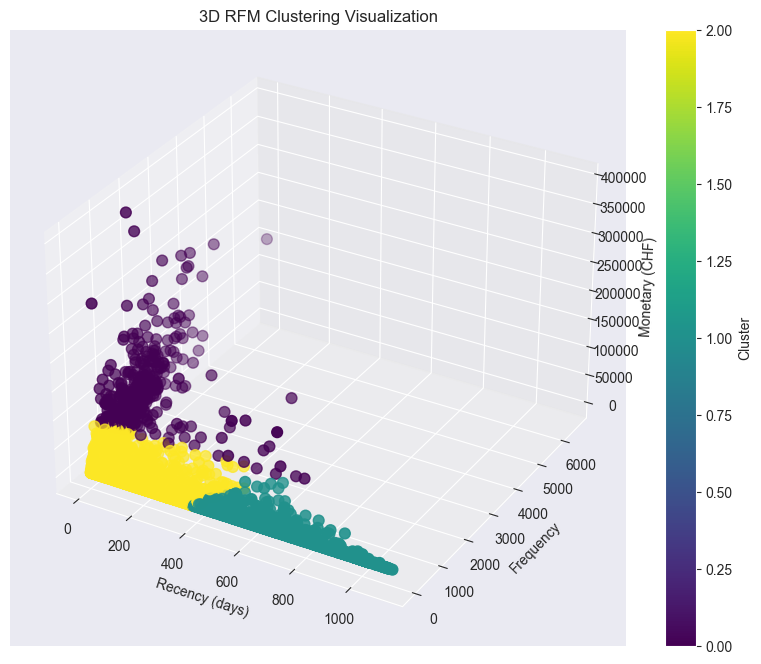

In [138]:
#3D Plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    rfm_new_df["Recency"],
    rfm_new_df["Frequency"],
    rfm_new_df["Monetary"],
    c=rfm_new_df["cluster"],
    cmap="viridis",
    s=60
)

ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary (CHF)")
ax.set_title("3D RFM Clustering Visualization")
plt.colorbar(sc, label="Cluster")
plt.show()

We merged the clustered customer data back with the original transaction dataset to enable deeper analysis. This allows us to link each transaction to a specific user segment (heavy, normal, or low user) and further explore differences in spending patterns, timing, and category preferences across these clusters.

In [139]:
new_df_transaction = df_transaction.merge(rfm_new_df[["customer_id", "cluster", "user_type"]], on="customer_id", how="left")
print(new_df_transaction)

                                  customer_id country  type  \
0        d4c13def-7173-4d71-a2a7-11a8b3e4db5f      ie  ecom   
1        e6315ccb-076d-40dd-9821-d57ad47d07fd      ch  ecom   
2        b6609a82-4d46-49ae-a273-588475160457      ch  ecom   
3        6e341a58-147c-4716-a6f0-220970ffb069      ch  ecom   
4        6e341a58-147c-4716-a6f0-220970ffb069      ch  ecom   
...                                       ...     ...   ...   
1508895  3c5d0be0-5ecc-4d21-a6da-c0e80977302f      us  ecom   
1508896  bf3df3c5-3b5a-46ce-bbd7-ab7862c446e4      ch   pos   
1508897  921fb3d2-1f91-4644-bf74-1622590886f5      de  ecom   
1508898  af222946-72b2-4fe5-b88c-1263515a99c4      ch  ecom   
1508899  d290409c-5edf-4135-a599-1276e46f745f      ch   pos   

                         trx_date  amount_chf orig_currency       category  \
0       2021-01-01 00:06:27+00:00       25.50           chf  communication   
1       2021-01-01 00:20:09+00:00       19.90           chf  communication   
2       2

We then identified what Heavy, Low and Normal users spend on.

In [140]:
print(new_df_transaction["user_type"].head(n=10))

0    normal
1       low
2    normal
3       low
4       low
5     heavy
6       low
7     heavy
8       low
9     heavy
Name: user_type, dtype: object


0    normal
1       low
2    normal
3       low
4       low
5     heavy
6       low
7     heavy
8       low
9     heavy
Name: user_type, dtype: object


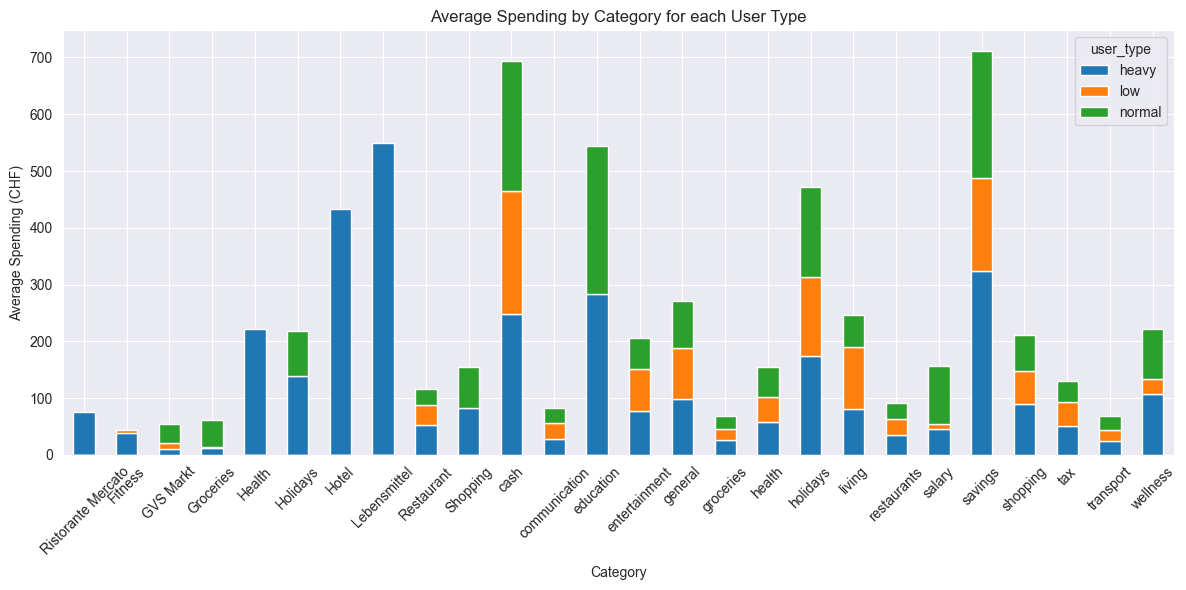

In [141]:
print(new_df_transaction["user_type"].head(n=10))
# Mean spending by User Type and Category
df_summary = (
    new_df_transaction
    .groupby(["user_type", "category"])["amount_chf"]
    .mean()
    .reset_index()
)

# Visualisation
df_pivot = df_summary.pivot(index="category", columns="user_type", values="amount_chf")
df_pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Average Spending by Category for each User Type")
plt.xlabel("Category")
plt.ylabel("Average Spending (CHF)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Pie Chart of spending patterns for each user segment.

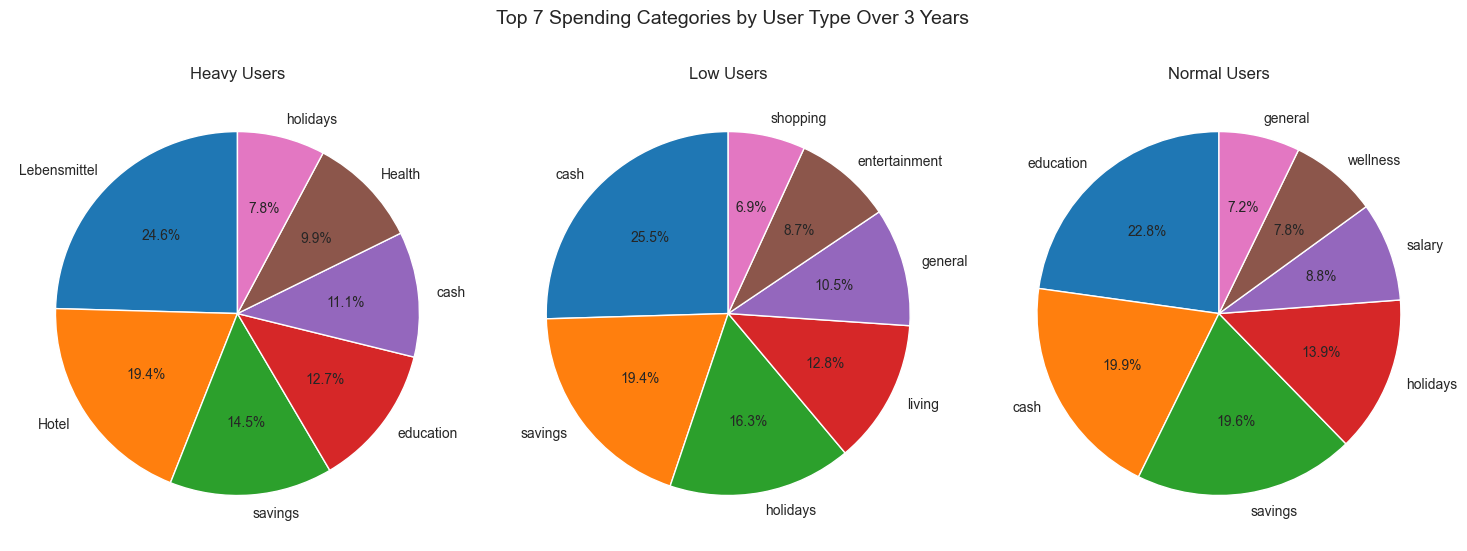

In [142]:
#Get unique user types
user_types = df_summary["user_type"].unique()

#Create plots for each user type
fig, axes = plt.subplots(1, len(user_types), figsize=(15, 6))

for ax, user in zip(axes, user_types):
    #Filter for that user type
    data = df_summary[df_summary["user_type"] == user]

    #Keep only top 7 categories
    data = data.sort_values("amount_chf", ascending=False).head(7)

    #Plot pie chart
    ax.pie(
        data["amount_chf"],
        labels=data["category"],
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"{user.capitalize()} Users")

plt.suptitle("Top 7 Spending Categories by User Type Over 3 Years", fontsize=14)
plt.tight_layout()
plt.show()

We compared monthly spending patterns per segment by selecting each segment’s own top 4 categories and aggregating totals by month. We also filled gaps in the timeline (full monthly index) to keep trends continuous and comparable. The resulting line charts show how heavy, normal, and low users differ in what they spend on and when their spending peaks.

/var/folders/fj/gqfb2nt92l5_hcv1xd9_sf7r0000gn/T/ipykernel_28807/2378289679.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  new_df_transaction["month"] = new_df_transaction["trx_date"].dt.to_period("M").dt.to_timestamp()


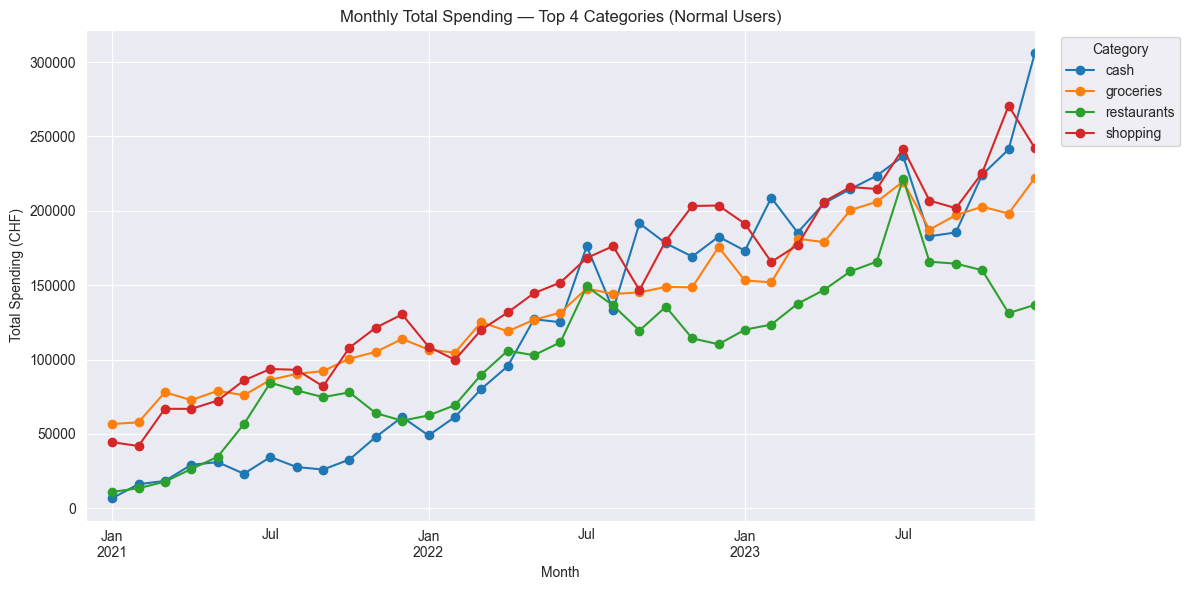

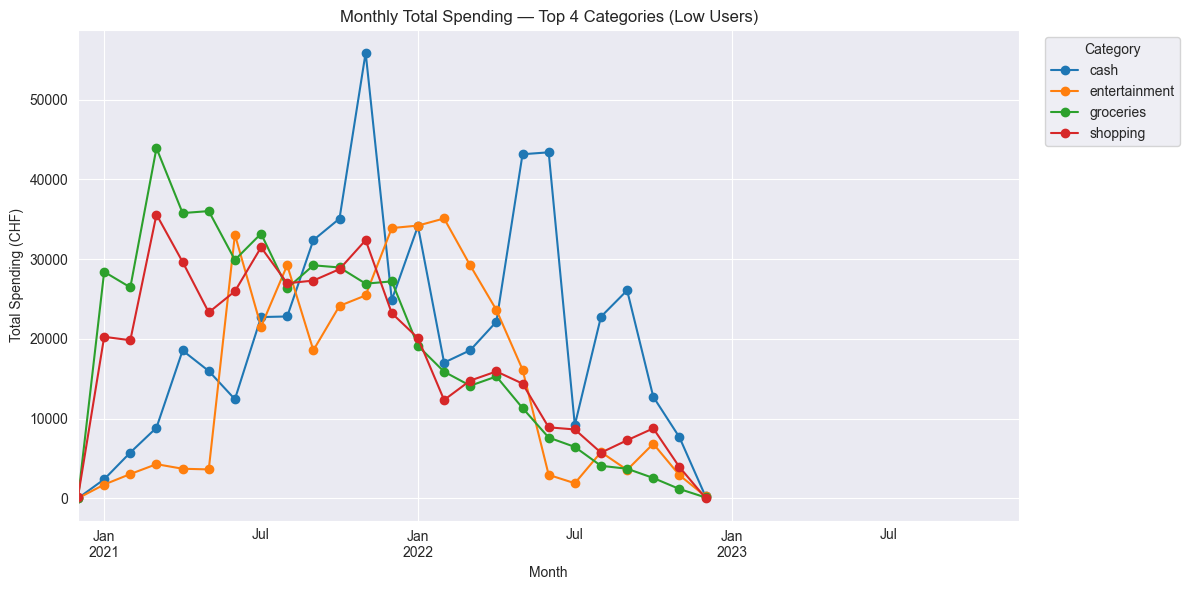

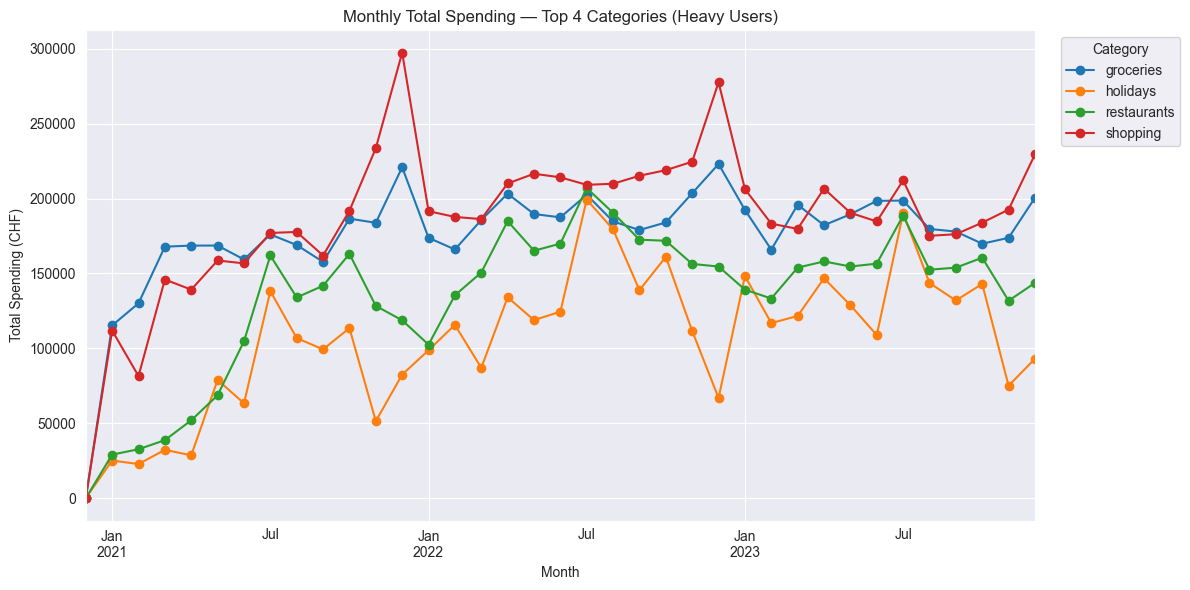

In [143]:
# Weekly expenditure on categories between heavy, low and normal users
# Setting the trx_date column as a datetime data type
new_df_transaction["trx_date"] = pd.to_datetime(new_df_transaction["trx_date"], errors="coerce")

# Month period as month-start timestamp
new_df_transaction["month"] = new_df_transaction["trx_date"].dt.to_period("M").dt.to_timestamp()

# Full monthly range for reindexing
all_months = pd.date_range(
    new_df_transaction["month"].min(),
    new_df_transaction["month"].max(),
    freq="MS"
)

# Loop for each User Type
for ut in new_df_transaction["user_type"].dropna().unique():
    d = new_df_transaction[new_df_transaction["user_type"] == ut]

    # Subsetting only Top 4 categories by total amount for each user Type
    top4 = (d.groupby("category")["amount_chf"]
              .sum()
              .sort_values(ascending=False)
              .head(4)
              .index)

    d_top = d[d["category"].isin(top4)]

    # Monthly totals per category
    mat = (d_top.groupby(["month", "category"], observed=False)["amount_chf"]
                .sum()
                .unstack("category", fill_value=0)
                .reindex(all_months))

    # Plot
    ax = mat.plot(figsize=(12,6), marker="o")
    ax.set_title(f"Monthly Total Spending — Top 4 Categories ({ut.capitalize()} Users)")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Spending (CHF)")
    ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

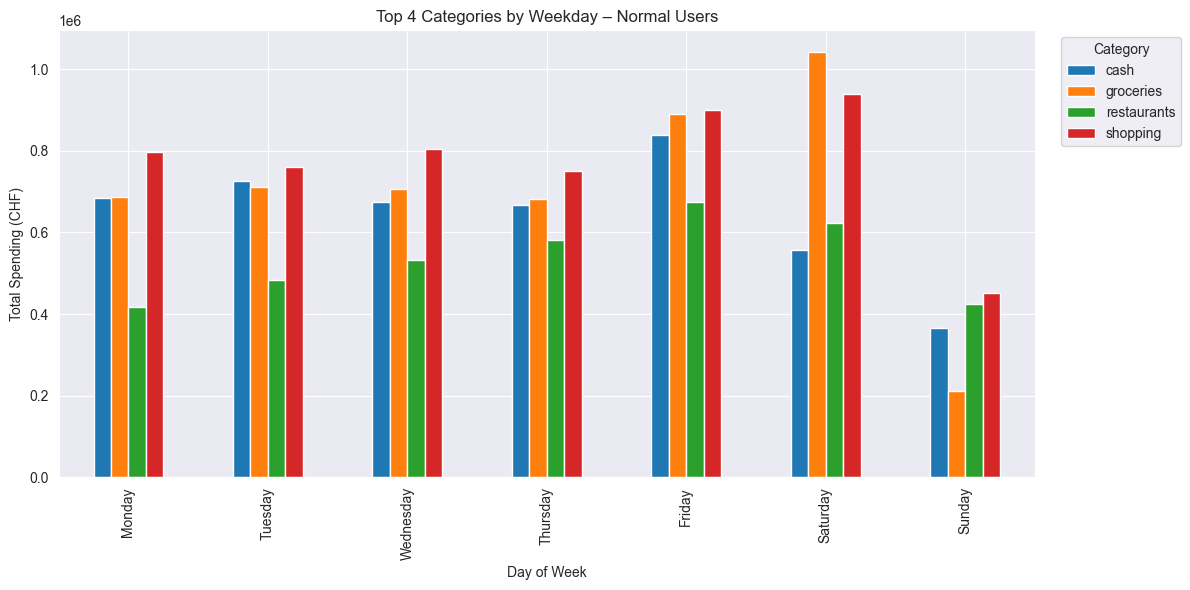

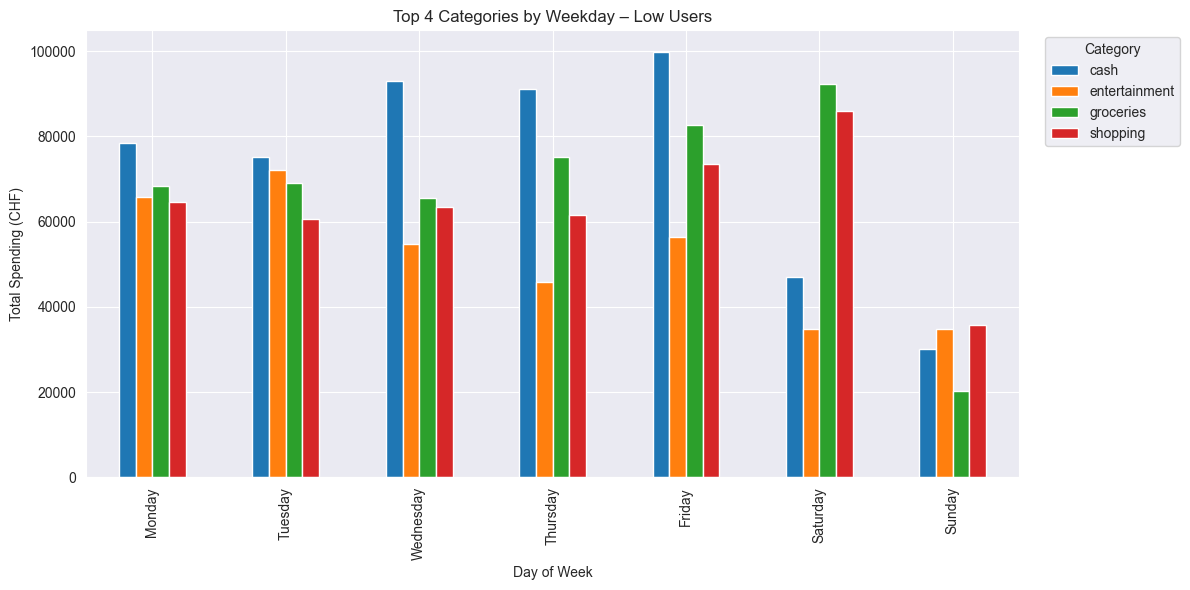

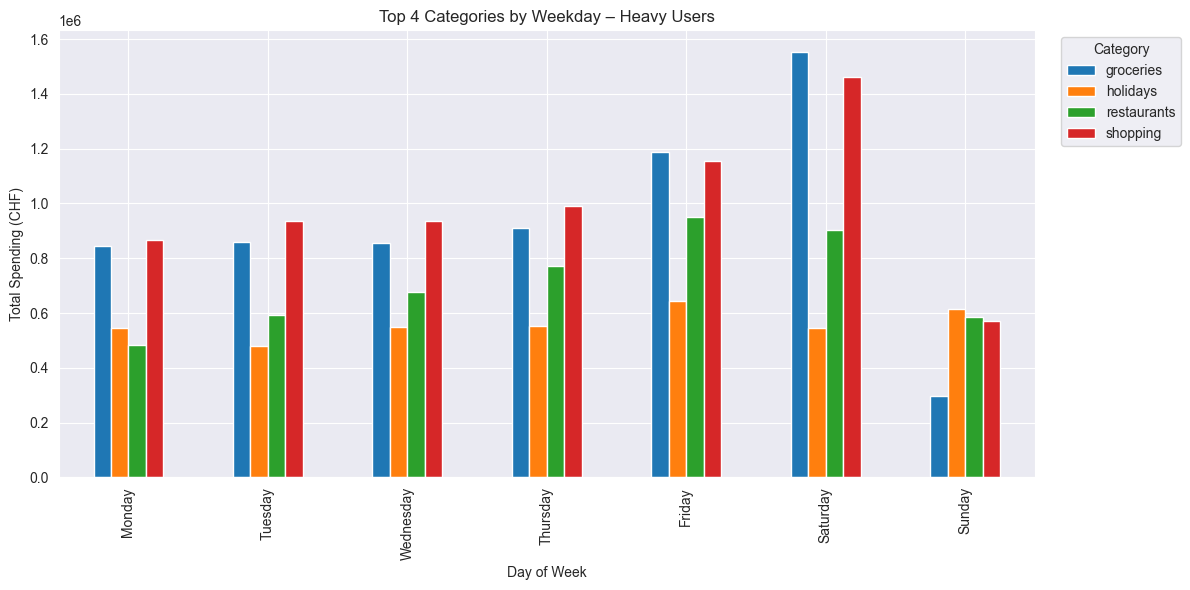

In [144]:
# Add weekday column
new_df_transaction["weekday"] = new_df_transaction["trx_date"].dt.day_name()

# Define weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Loop through each user type
for user in new_df_transaction["user_type"].unique():
    # Filter for each user type
    df_user = new_df_transaction[new_df_transaction["user_type"] == user]

    # Find top 4 categories by total spend for that user type
    top_categories = (
        df_user.groupby("category")["amount_chf"]
               .sum()
               .sort_values(ascending=False)
               .head(4)
               .index
    )

    # Keep only the top 4 categories for each user type
    df_user = df_user[df_user["category"].isin(top_categories)]

    # Group by weekday and category
    df_weekday = (
        df_user.groupby(["weekday", "category"])["amount_chf"]
                .sum()
                .unstack("category", fill_value=0)
                .reindex(weekday_order)
    )

    # Plot
    df_weekday.plot(kind="bar", figsize=(12,6))
    plt.title(f"Top 4 Categories by Weekday – {user.capitalize()} Users")
    plt.xlabel("Day of Week")
    plt.ylabel("Total Spending (CHF)")
    plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

We then identified where Heavy, Low and Normal Users spend.

In [145]:
# Exploring the unique countries in the country column
new_df_transaction["country"].unique()

array(['ie', 'ch', 'de', 'gb', 'cr', 'nl', 'mt', 'pe', 'mx', 'sg', 'us',
       'es', 'lu', 'se', 'fr', 'cy', 'tr', 'lt', 'jp', 'br', 'at', 'it',
       'hk', 'bs', 'il', 'dk', 'gh', 'pl', 'li', 'gr', 'ca', 'au', 'sk',
       'lk', 'eg', 'cz', 'bg', 'lv', 'is', 'ar', 'si', 'be', 'mv', 'ae',
       'my', 'cl', 'ru', 'md', 'pt', 'sm', 'mk', 'ee', '900', 'az', 'gi',
       'fi', 'id', 'no', 'tj', 'tw', 'co', 'ke', 'hr', 'za', 'ro', 'ba',
       'ng', 'hu', 'na', 'do', 'am', 'nz', 'th', 'tz', 'tn', 'pa', 'in',
       'mc', 'me', 'va', 'py', 'rs', 'kg', 'vn', 'qzz', 'kr', 'ma', 'uz',
       'sc', 'ad', 'aw', 'qa', 'ug', 'kz', 'qz', 'mu', 'ec', 'ph', 'pf',
       'om', 'jm', 'jo', 'lr', 'uy', 'cv', 'sn', 'al', 'gt', 'gp', 'mq',
       'bz', 'fo', 'sx', 'mf', 'cn', 'ge', 'ci', 'bh', 'sa', 'ag', 'gm',
       'rw', 'sz', 'mz', 'kn', 'kh', nan, 'pr', 'la', 'pk', 'bw', 'cw',
       're', 'ps', 'nc', 'et', 'np', 'fj', 'bo', 'mg', 'kw', 'bb', 'tc',
       'lc', 'tg', 'bj', 'vg', 'mw', 'che', 'ck', 

In [146]:
# Average amount people Spend in Switzerland Over 3 years
ch_df = new_df_transaction[new_df_transaction["country"] == "ch"]
ch_df.groupby("user_type")["amount_chf"].mean()

user_type
heavy     41.017191
low       34.704784
normal    36.249943
Name: amount_chf, dtype: float64

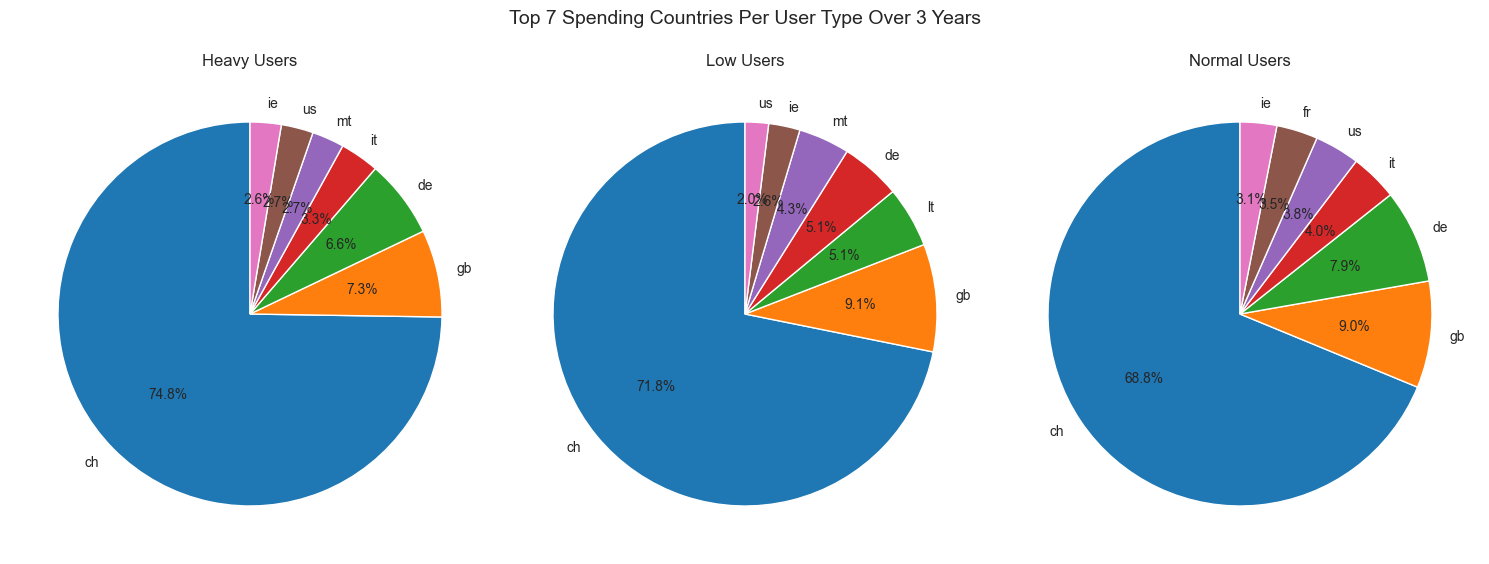

In [147]:
# Total spending by User Type and Category
df_summary_1 = (
    new_df_transaction
    .groupby(["user_type", "country"])["amount_chf"]
    .sum()
    .reset_index()
)

# Get unique user types
user_types = df_summary_1["user_type"].unique()

# Create plots for each user type
fig, axes = plt.subplots(1, len(user_types), figsize=(15, 6))

for ax, user in zip(axes, user_types):
    #Filter for that user type
    data = df_summary_1[df_summary_1["user_type"] == user]

    #Keep only top 7 categories
    data = data.sort_values("amount_chf", ascending=False).head(7)

    #Plot pie chart for each User type with Separate Titles
    ax.pie(
        data["amount_chf"],
        labels=data["country"],
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"{user.capitalize()} Users")

# Overall Title for the Entire plots
plt.suptitle("Top 7 Spending Countries Per User Type Over 3 Years", fontsize=14)
plt.tight_layout()
plt.show()

We then identified, at which point in time Heavy, Low and Normal users spend.

In [148]:
print(new_df_transaction["type"].unique())

['ecom' 'pos' nan]


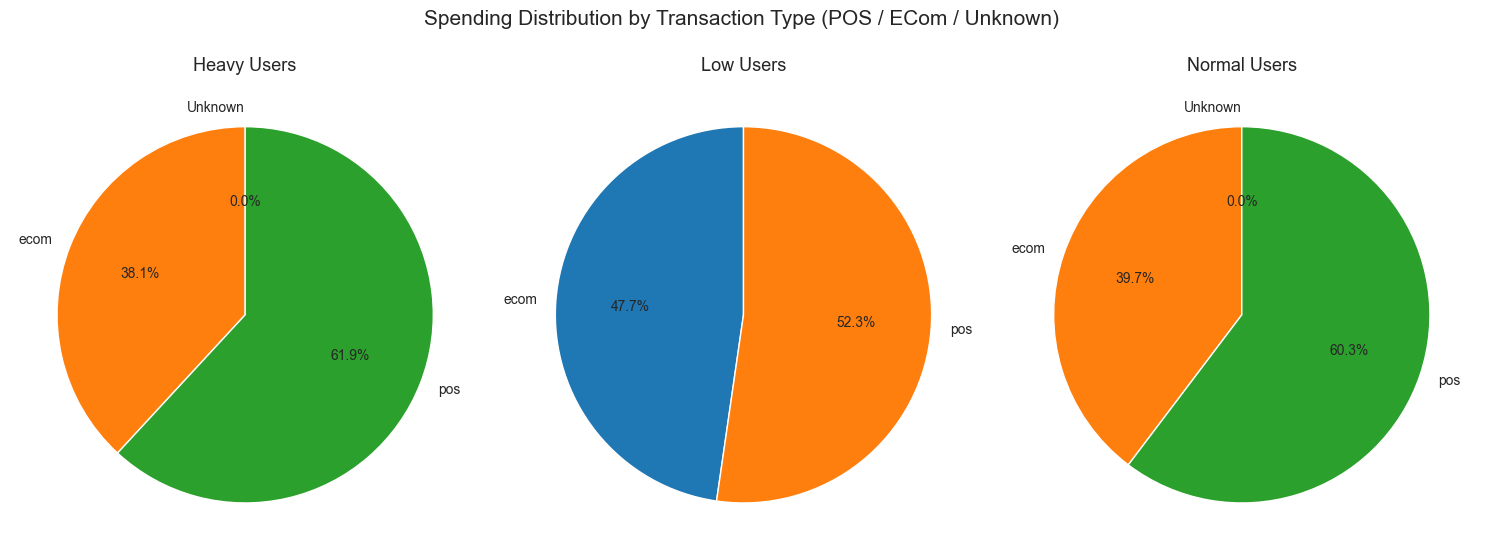

In [149]:
# Replace NaN in 'type' for Unknown
new_df_transaction["type"] = new_df_transaction["type"].fillna("Unknown")

# Group and sum total spending for each user type on each type
df_summary_2 = (
    new_df_transaction
    .groupby(["user_type", "type"])["amount_chf"]
    .sum()
    .reset_index()
)

# Get unique user types
user_types = df_summary_2["user_type"].unique()

# Create subplots
fig, axes = plt.subplots(1, len(user_types), figsize=(15, 6))

# Loop through each user type and create a pie chart
for ax, user in zip(axes, user_types):
    data = df_summary_2[df_summary_2["user_type"] == user]

    # Plot pie chart
    wedges, texts, autotexts = ax.pie(
        data["amount_chf"],
        labels=data["type"],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 10}
    )

    # Creating a Separate Title for each subplot
    ax.set_title(f"{user.capitalize()} Users", fontsize=13)

# Overall title
plt.suptitle("Spending Distribution by Transaction Type (POS / ECom / Unknown)", fontsize=15)
plt.tight_layout()
plt.show()